<a href="https://colab.research.google.com/github/Habibmaryam/sales-prediction-using-multilinear-regression/blob/main/Predicting_sales_using_Multiple_linear_regression_OLS_method.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mini Project: Perform Multiple Linear Regression

## Overview
This project focuses on using multiple linear regression to analyze the relationship between sales and various marketing promotion strategies. By leveraging multiple independent variables, such as TV, social media, radio, and influencer promotions, we aim to build a predictive model that estimates sales based on these factors. This project will cover the complete data science pipeline, including data exploration, preprocessing, model building, evaluation, and interpretation.

## Objective
Develop a multiple linear regression model to predict sales based on marketing promotion data. The project will involve exploring the dataset, selecting relevant independent variables, fitting the model, checking assumptions, and interpreting the results to provide actionable insights.

## Learning Outcomes
1. Understand the concept of multiple linear regression and its applications.
2. Learn to preprocess and explore data for regression analysis.
3. Gain experience in fitting and evaluating a multiple linear regression model.
4. Check and validate regression assumptions.
5. Interpret model coefficients and communicate results to stakeholders.

---


## Step 1: Define the Problem
### Task:
Understand the problem and its real-world implications. The goal is to predict sales based on various marketing promotion strategies, which can help the business optimize its marketing efforts and allocate resources effectively.

### Mini-task:
Write a brief paragraph on how predicting sales using multiple linear regression can benefit the business.

---

Multiple linear regression uses multiple predictors (independent variables) for prediction.It has various benefits. Some benefits of using multiple linear regression to predict the sales on a business.

1. Predicting sales using multiple linear regression can significantly benefit a business by identifying and quantifying the impact of various factors such as pricing, advertising spend, seasonality, and customer demographics on sales performance.

2. This helps to enable data-driven decision-making, helping businesses allocate resources more effectively, forecast future revenue with greater accuracy, and adjust strategies proactively to maximize profitability.

3. Multiple linear regression prediction can result in businesses understanding the relationships between different variables and sales outcomes, businesses can uncover hidden trends and optimize operations to drive growth.

## Step 2: Data Collection
### Task:
Collect the dataset required for building the regression model. The dataset used in this project is `marketing_sales_data.csv`, which contains information about TV, social media, radio, and influencer promotions, along with sales data.

### Mini-task:
Load the dataset and inspect the first few rows to understand its structure.

#### Hint:
Use the `pandas` library to load the dataset and display the first five rows.

```python
import pandas as pd

# Load the dataset
data = pd.read_csv('marketing_sales_data.csv')

# Display the first five rows
### print(f'First five rows of the data set:')
### data.head() ###
```

---

In [3]:
# Display first five rows
import pandas as pd
data = pd.read_csv('/content/sample_data/marketing_sales_data.csv')
print(f'First five rows of the data set:')
data.head()

First five rows of the data set:


,TV,Radio,Social Media,Influencer,Sales
0,Low,3.518070,2.293790,Micro,55.261284
1,Low,7.756876,2.572287,Mega,67.574904
2,High,20.348988,1.227180,Micro,272.250108
3,Medium,20.108487,2.728374,Mega,195.102176
4,High,31.653200,7.776978,Nano,273.960377


In [4]:
shape = data.shape
print(f"The data has {shape[0]} rows and {shape[1]} columns")

The data has 572 rows and 5 columns


In [5]:
column_name = data.columns
print(f"This data set consists of the follwing column names:,\n{column_name}")

This data set consists of the follwing column names:,
Index(['TV', 'Radio', 'Social Media', 'Influencer', 'Sales'], dtype='object')


In [6]:
# Display the sumnmary statistics of the dataset
data.describe()

,Radio,Social Media,Sales
count,572.000000,572.000000,572.000000
mean,17.520616,3.333803,189.296908
std,9.290933,2.238378,89.871581
min,0.109106,0.000031,33.509810
25%,10.699556,1.585549,118.718722
50%,17.149517,3.150111,184.005362
75%,24.606396,4.730408,264.500118
max,42.271579,11.403625,357.788195


In [7]:
# Display basic information about the dataset
print("\nDataset information:")
data.info()


Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 572 entries, 0 to 571
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TV            572 non-null    object 
 1   Radio         572 non-null    float64
 2   Social Media  572 non-null    float64
 3   Influencer    572 non-null    object 
 4   Sales         572 non-null    float64
dtypes: float64(3), object(2)
memory usage: 22.5+ KB


In [8]:
# Import Data Files from Google Drive

import requests
import pandas as pd
from io import StringIO
def read_gd(sharingurl):
    file_id = sharingurl.split('/')[-2]
    download_url='https://drive.google.com/uc?export=download&id=' + file_id
    url = requests.get(download_url).text
    csv_raw = StringIO(url)
    return csv_raw

url = "https://drive.google.com/file/d/1WChLou3qt_JaPjYLZBMHJ8WxSssQ-enL/view?usp=drive_link"
gdd = read_gd(url)

df = pd.read_csv(gdd)

df.head()

,TV,Radio,Social Media,Influencer,Sales
0,Low,3.518070,2.293790,Micro,55.261284
1,Low,7.756876,2.572287,Mega,67.574904
2,High,20.348988,1.227180,Micro,272.250108
3,Medium,20.108487,2.728374,Mega,195.102176
4,High,31.653200,7.776978,Nano,273.960377


## Step 3: Exploratory Data Analysis (EDA)
### Task:
Analyze the dataset to understand the distribution of variables, identify relationships between variables, and prepare the data for modeling.

### Mini-task:
Create a pairplot to visualize the relationships between continuous variables in the dataset.

#### Hint:
Use `seaborn.pairplot()` to create a pairplot of the continuous variables.

```python
import seaborn as sns

# Create a pairplot of the continuous variables

### import matplotlib.pyplot as plt
plt.figure(figsize=(10, 8))
sns.pairplot(df)
plt.suptitle('Pairplot of Continuous Variables', y=1.02)
plt.show() ###
```

---

<ipython-input-18-2f15f43aa46f>:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=channel_spend.index, y=channel_spend.values, palette=['red', 'blue'])  # Now, x-axis values are strings


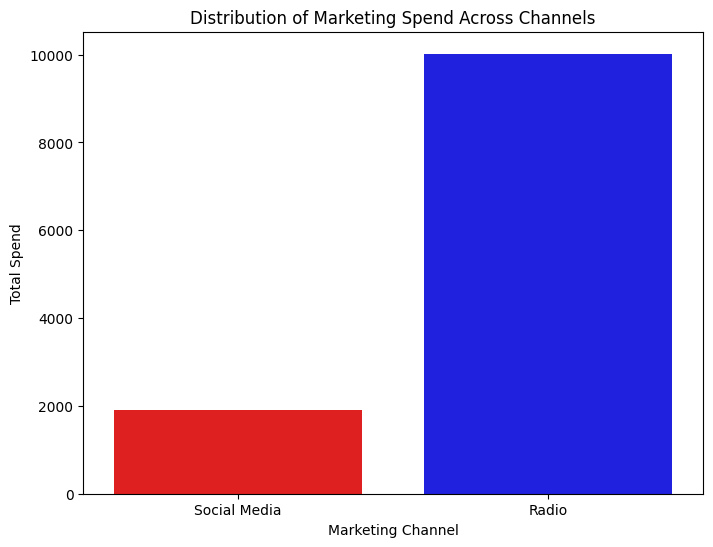

<Figure size 640x480 with 0 Axes>

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'data' is your DataFrame and contains columns for each marketing channel spend

# Calculate total spend for each channel
channel_spend = data[['Social Media', 'Radio']].sum()

# Convert the index to strings
channel_spend.index = channel_spend.index.astype(str)

# Create bar chart
plt.figure(figsize=(8, 6))  # Adjust figure size as needed
sns.barplot(x=channel_spend.index, y=channel_spend.values, palette=['red', 'blue'])  # Now, x-axis values are strings
plt.title('Distribution of Marketing Spend Across Channels')
plt.xlabel('Marketing Channel')
plt.ylabel('Total Spend')
plt.show()

# Save the chart as an image to include in your presentation
plt.savefig('marketing_spend_distribution.png')

The bar chart titled **"Distribution of Marketing Spend Across Channels"** illustrates the total marketing expenditure allocated to two channels: social media and radio. From the chart, it is evident that Radio received a significantly higher investment, with a total spend of approximately **10,000 units**, compared to Social Media, which received just under **2,000 units**. This highlights a strategic emphasis on radio as the dominant medium for marketing in this context.

This spending distribution suggests that the organization may view **radio** as a more effective or accessible channel for reaching its target audience. It could be due to the audience's media consumption habits, greater coverage in rural or traditional areas, or higher perceived return on investment. Conversely, the lower allocation to **social media** may reflect limited digital adoption among the audience, budget constraints, or an underdeveloped online marketing strategy. However, given the global shift toward digital platforms, the organization might benefit from re-evaluating its strategy to balance traditional and digital outreach more effectively.

<Figure size 1000x800 with 0 Axes>

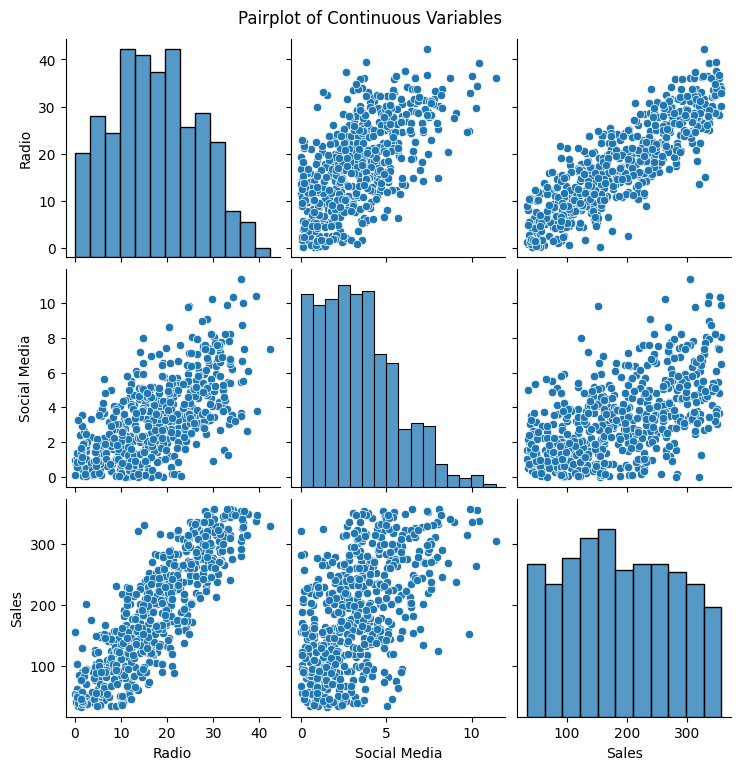

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 8))
sns.pairplot(df)
plt.suptitle('Pairplot of Continuous Variables', y=1.02)
plt.show()

The pair plot shows three continuous variables;Radio spend, Social Media spend, and Sales—using histograms on the diagonal and scatter plots off-diagonal.

**Distributions:**

Radio spend ranges from 0 to 45, fairly evenly spread with a slight right tail.

Social Media spend is mostly between 0 and 6, tapering off toward 10, indicating a right-skew.

Sales fall mainly between 100 and 300, forming a near bell shape, though a bit flat on top.

**Scatter plots:**

Radio vs. Social Media: A weak to moderate positive relationship—higher spending on one often aligns with the other, but with a wide spread.

Radio vs. Sales: A strong, nearly linear relationship which implies more Radio spend results to more Sales.

Social Media vs. Sales: A moderate positive trend indicating Sales rise with Social Media spend, but the pattern is not so clear.

**Overall:**

 * Ad spend and Sales move in the same direction; that is the higher the ad spend, the more the sales.

* Radio is the strongest predictor of Sales, followed by Social Media.

* The weaker link between Radio and Social Media budgets suggests flexibility in campaign strategies, but either way, increasing spend tends to boost Sales.


## Step 4: Data Preparation
### Task:
Prepare the data for regression analysis by handling missing values, encoding categorical variables, and splitting the data into training and testing sets.

### Mini-task:
Drop rows with missing values and encode categorical variables if necessary.

#### Hint:
Use `data.dropna()` to remove rows with missing values and `pd.get_dummies()` to encode categorical variables.

```python
# Drop rows with missing values
### data.dropna(inplace=True) ###

# Encode categorical variables (if needed)
### Ydata_encoded = pd.get_dummies(data)
data_encoded.head() ###
```

---

In [11]:
# Drop rows with missing values
data.dropna(inplace=True)

# Encode categorical variables
data_encoded = pd.get_dummies(data)
data_encoded.head()

,Radio,Social Media,Sales,TV_High,TV_Low,TV_Medium,Influencer_Macro,Influencer_Mega,Influencer_Micro,Influencer_Nano
0,3.518070,2.293790,55.261284,False,True,False,False,False,True,False
1,7.756876,2.572287,67.574904,False,True,False,False,True,False,False
2,20.348988,1.227180,272.250108,True,False,False,False,False,True,False
3,20.108487,2.728374,195.102176,False,False,True,False,True,False,False
4,31.653200,7.776978,273.960377,True,False,False,False,False,False,True


In [12]:
print(data_encoded.columns)

Index(['Radio', 'Social Media', 'Sales', 'TV_High', 'TV_Low', 'TV_Medium',
       'Influencer_Macro', 'Influencer_Mega', 'Influencer_Micro',
       'Influencer_Nano'],
      dtype='object')


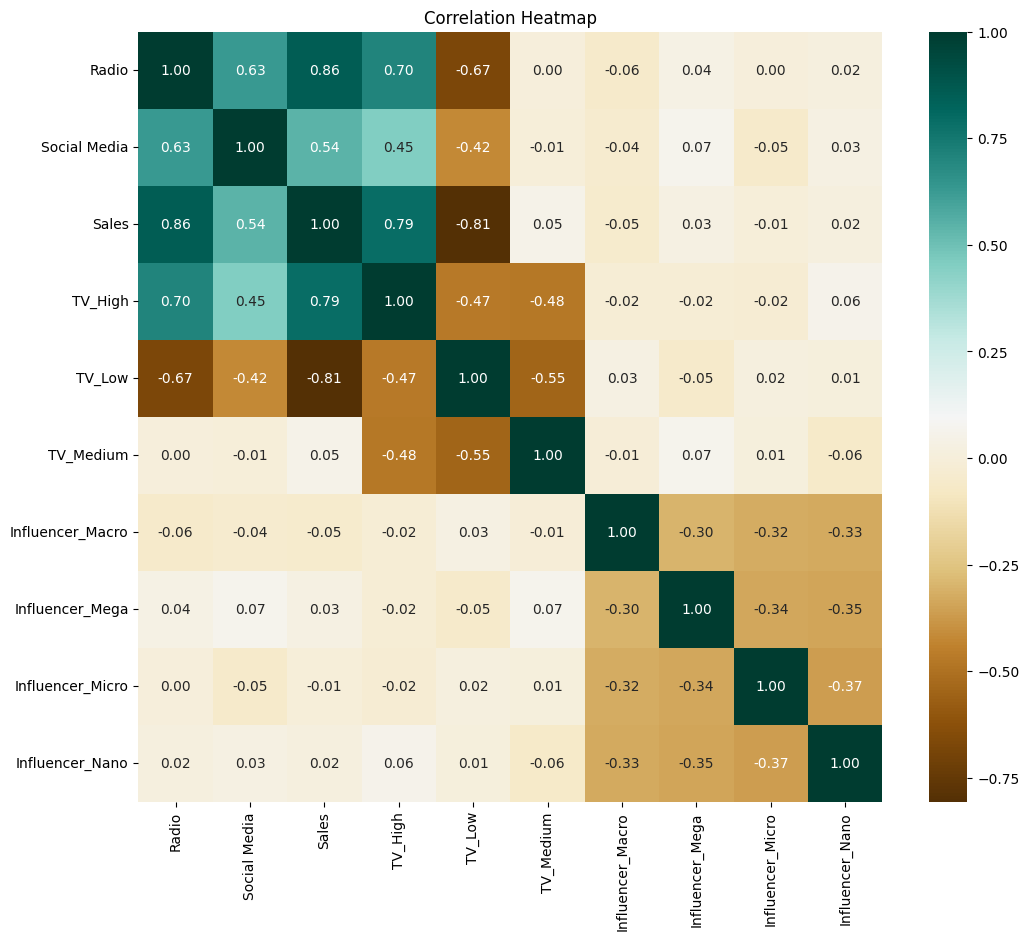

In [13]:
# Calculate the correlation matrix
correlation_matrix = data_encoded.corr()

# Create the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='BrBG', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

Key Findings from the Heatmap
* Strong Positive Correlation:
Radio vs Sales (0.86): Very strong relationship. As Radio spending increases, Sales tend to increase significantly.

* TV_High vs Sales (0.79): High TV spending is strongly associated with increased sales.

* Radio vs TV_High (0.70): These budgets tend to rise together, possibly due to joint marketing campaigns.

* Strong Negative Correlation:
TV_Low vs Sales (-0.81): Low TV spending is strongly associated with lower sales which is suggesting higher TV budgets perform better.

* TV_Low vs Radio (-0.67): When TV spending is low, radio spending tends to be higher, possibly indicating a trade-off in ad budgeting.

* Weak or No Correlation:
Influencer variables (Macro, Mega, Micro, Nano) show very weak or no correlation with Sales (mostly around -0.05 to 0.03). This might imply:

* Influencer marketing in your dataset isn’t driving sales.

* Or, its effects are nonlinear or delayed, that is, not captured by simple correlation.

* Neutral Relationships:
TV_Medium has nearly zero correlation with most variables, including Sales (0.05). Its impact seems negligible in this case.

## Step 5: Model Building
### Task:
Fit a multiple linear regression model to predict sales using the selected independent variables.

### Mini-task:
Define the OLS formula and fit the model using the `statsmodels` library.

#### Hint:
Use `statsmodels.formula.api.ols()` to define the model and fit it to the data.

```python
import statsmodels.formula.api as smf

# Define the OLS formula
### YOUR CODE HERE ###

# Fit the model
### YOUR CODE HERE ###

# Display the model summary
### YOUR CODE HERE ###
```

---

In [14]:
import statsmodels.formula.api as smf
# Rename the social media column
data_encoded.rename(columns={"Social Media": "Social_Media"}, inplace=True)

# Define the OLS formula
formula = 'Sales ~ Radio + Social_Media + TV_High + TV_Low + TV_Medium + Influencer_Macro + Influencer_Mega + Influencer_Micro + Influencer_Nano'

# Fit the model
model = smf.ols(formula, data=data_encoded).fit()

# Display the model summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.904
Model:                            OLS   Adj. R-squared:                  0.903
Method:                 Least Squares   F-statistic:                     760.4
Date:                Thu, 01 May 2025   Prob (F-statistic):          1.82e-282
Time:                        21:33:48   Log-Likelihood:                -2713.4
No. Observations:                 572   AIC:                             5443.
Df Residuals:                     564   BIC:                             5478.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

## Step 6: Model Evaluation
### Task:
Evaluate the model by checking the regression assumptions, including linearity, independence, normality, constant variance, and multicollinearity.

### Mini-task:
Create scatterplots to check the linearity assumption and calculate the residuals to check the normality assumption.

#### Hint:
Use `seaborn.scatterplot()` to create scatterplots and `statsmodels.qqplot()` to check the normality of residuals.

```python
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Create scatterplots for linearity
### YOUR CODE HERE ###

# Calculate residuals and create a Q-Q plot
### YOUR CODE HERE ###
```

---

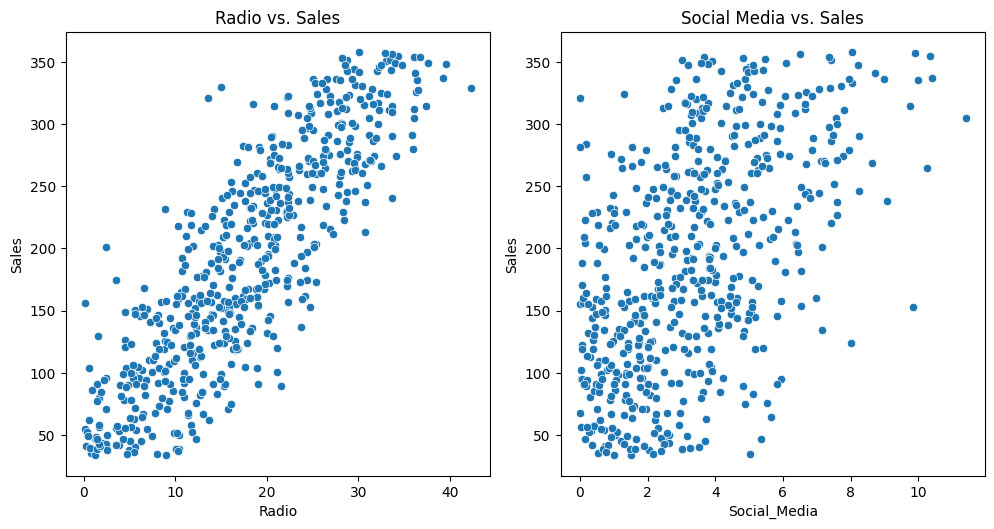

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'data_encoded' is your DataFrame

# Create scatterplots for linearity
plt.figure(figsize=(15, 15))  # Increased figure size to accommodate more plots

# Scatterplot for Radio vs. Sales
plt.subplot(3, 3, 1)  # Adjusted subplot grid
sns.scatterplot(x='Radio', y='Sales', data=data_encoded)
plt.title('Radio vs. Sales')

# Scatterplot for Social Media vs. Sales
plt.subplot(3, 3, 2)
sns.scatterplot(x='Social_Media', y='Sales', data=data_encoded)
plt.title('Social Media vs. Sales')


plt.tight_layout()
plt.show()

**Radio vs. Sales**

This shows a strong positive linear relationship.

As Radio spend increases, Sales increase almost proportionally.

The data points are closely clustered along an upward-sloping trend, indicating:

Radio is a strong predictor of Sales.

A linear model (like OLS regression) is well-suited for this relationship.

**Social Media vs. Sales**

This shows a weaker, noisier positive relationship.

While higher Social Media spend tends to correlate with higher Sales, the scatter is wide and less defined.

Many different sales values are associated with the same Social Media spend levels, especially in the lower range (0–4 units).

**This could suggest:**

Diminishing returns or inconsistent effectiveness of social media spend.

Possible nonlinear or interaction effects.

Or that other factors are influencing the impact of Social Media ads.

Social Media vs. Sales
This shows a weaker, noisier positive relationship.

While higher Social Media spend tends to correlate with higher Sales, the scatter is wide and less defined.

Many different sales values are associated with the same Social Media spend levels, especially in the lower range (0–4 units).

**This could suggest:**

Diminishing returns or inconsistent effectiveness of social media spend.

Possible nonlinear or interaction effects.

Or that other factors are influencing the impact of Social Media ads.


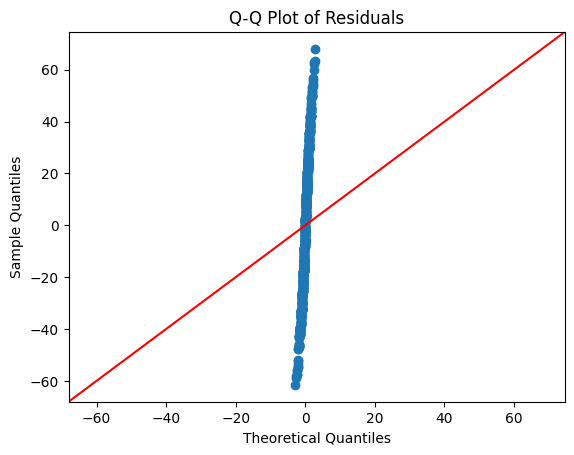

In [16]:
import statsmodels.api as sm

# Get residuals from the fitted model
residuals = model.resid

# Q-Q plot
sm.qqplot(residuals, line='45')
plt.title('Q-Q Plot of Residuals')
plt.show()



**What the plot indicates:**

The residuals deviate strongly from the red line, forming a narrow vertical band instead of roughly following the 45-degree line.

This suggests that the residuals are not normally distributed.

Specifically, the spread of the residuals is much more compressed horizontally than expected, which often points to non-normality or some transformation issue


## Step 7: Results and Interpretation
### Task:
Interpret the model results, including the R-squared value, coefficients, and their statistical significance.

### Mini-task:
Display the model summary and interpret the coefficients.

#### Hint:
Use `model.summary()` to display the model results and interpret the coefficients.

```python
# Display the model summary
### YOUR CODE HERE ###

# Interpret the coefficients
### YOUR CODE HERE ###
```

---

In [17]:
# Display the model summary
print(model.summary())

# Access coefficients
coefficients = model.params

# Print coefficients with interpretations
for variable, coefficient in coefficients.items():
    print(f"Coefficient for {variable}: {coefficient:.2f}")
    if variable == 'Intercept':
        print(f"  Interpretation: When all other predictors are 0, the estimated Sales is {coefficient:.2f}.")
    else:
        print(f"  Interpretation: Holding other predictors constant, a one-unit increase in {variable} is associated with a {coefficient:.2f} unit change in Sales.")

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.904
Model:                            OLS   Adj. R-squared:                  0.903
Method:                 Least Squares   F-statistic:                     760.4
Date:                Thu, 01 May 2025   Prob (F-statistic):          1.82e-282
Time:                        21:33:49   Log-Likelihood:                -2713.4
No. Observations:                 572   AIC:                             5443.
Df Residuals:                     564   BIC:                             5478.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

## Considerations
**What are some key takeaways you learned from this project?**
- Reflect on the importance of checking regression assumptions and interpreting model coefficients.
- Consider how the model's insights can be used to optimize marketing strategies.

**How would you share your findings with a team?**
- Prepare a presentation with visualizations and key metrics.
- Discuss the impact of different marketing strategies on sales.

**What would you share with and recommend to stakeholders?**
- Highlight the key factors that contribute most to sales.
- Recommend strategies to optimize marketing efforts based on the model's insights.

**Here are some key takeaways from this multiple linear regression project:**

1. Importance of Checking Regression Assumptions:

***Linearity:*** The scatterplots revealed that some variables exhibited a linear relationship with Sales (e.g., Radio), while others showed weaker or less clear patterns (e.g., Social Media). It's crucial to assess linearity to ensure the model is appropriate for the data.

***Normality of Residuals:*** The Q-Q plot indicated potential deviations from normality, suggesting that the residuals might not be perfectly normally distributed. This highlights the importance of checking this assumption, as violations can impact the validity of statistical inference.
Other Assumptions: While not explicitly checked in this project, it's important to also consider other regression assumptions like independence of errors, constant variance (homoscedasticity), and multicollinearity. These assumptions, if violated, can affect the reliability and interpretability of the model.

2. Interpreting Model Coefficients:

**Understanding Relationships:** By interpreting the coefficients, we can understand the direction and magnitude of the relationship between each marketing strategy and sales. For example, a positive coefficient for Radio suggests that increasing Radio spend is associated with higher Sales.
Statistical Significance: Checking the p-values associated with the coefficients helps determine which predictors have a statistically significant impact on sales. This information is crucial for identifying the most influential marketing strategies.
Contextual Interpretation: Coefficients should be interpreted in the context of the specific business and dataset. Understanding the units of measurement and the practical implications of the effects is essential for making informed decisions.

3. Optimizing Marketing Strategies:

**Resource Allocation:** The model's insights can guide resource allocation decisions. By identifying the most impactful marketing strategies, businesses can prioritize spending on those channels to maximize ROI.

**Strategic Adjustments:** The model can help identify areas where adjustments might be needed. For example, if a certain marketing strategy has a weak or negative effect on sales, the business might consider reducing investment in that area or exploring alternative approaches.

**Data-Driven Decisions:** The regression model provides a quantitative basis for making data-driven marketing decisions. Rather than relying solely on intuition or past practices, businesses can use the model's predictions and insights to develop more effective strategies.

In summary, this project highlights the importance of thoroughly checking regression assumptions, interpreting model coefficients carefully, and using the model's insights to guide marketing strategies for optimal results. By embracing a data-driven approach and leveraging statistical tools like multiple linear regression, businesses can make more informed decisions, allocate resources efficiently, and improve their overall marketing performance.

**How would you share your findings with a team?**

Answer: Here is how I would share my findings;

Project Goal:

To predict sales based on various marketing promotion strategies (TV, social media, radio, influencer) using multiple linear regression.

Data:

Dataset: marketing_sales_data.csv
Variables: TV, Social Media, Radio, Influencer (Macro, Mega, Micro, Nano), Sales
Analysis Steps:

Exploratory Data Analysis (EDA):
Pairplot: Visualized relationships between continuous variables. Strongest positive correlation observed between Radio spend and Sales.

Heatmap: Confirmed strong positive correlation between Radio, TV_High, and Sales. Influencer variables had weak to no correlation with Sales.

Data Preparation:
Missing Values: Rows with missing values were dropped.

Categorical Variables: Encoded using one-hot encoding (TV categories).

Model Building:
Used statsmodels to fit a multiple linear regression model.

Model Evaluation:
Linearity: Scatterplots visually assessed the linearity assumption.

Normality of Residuals: Q-Q plot revealed potential deviations from normality.

Results and Interpretation:
Model Summary: R-squared, coefficients, p-values.

Coefficients: Radio and TV_High had statistically significant positive coefficients. Influencer variables and TV_Medium had minimal impact.
Key Findings:

Radio advertising is the strongest predictor of sales.
TV advertising (high budget) also significantly impacts sales.

Influencer marketing showed little to no effect on sales in this dataset.

**Impact on marketing strategies on sales:**

the analysis strongly favors radio and high-budget TV advertising as the most effective marketing strategies for boosting sales. Social media advertising has a moderate impact but may require optimization, while the effectiveness of influencer marketing needs further investigation. TV advertising with lower budgets seems less effective.

**Recommendations:**

Prioritize radio and high-budget TV advertising for marketing campaigns.
Re-evaluate or further investigate the effectiveness of influencer marketing strategies.
Consider the limitations of the model due to potential deviations from normality of residuals.


# **END**